# Debug Pipeline — Palmprint Recognition
Visualisasi per-step sesuai `extractor.py` pipeline. 
**Input: gambar ROI hasil MediaPipe dari folder `debug_inputs/`** (sudah crop 200×200, grayscale).

> Pipeline aktif: **ROI → Quality Gate → Gabor+CLAHE → HOG-SGF → Scaler → PCA**
> `use_dog=False` — DoG dinonaktifkan.

In [5]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from skimage.feature import hog
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Path setup ──
BASE_DIR   = r'D:\xampp\htdocs\palmprint-backend\palmprint-ml'
DEBUG_DIR  = os.path.join(BASE_DIR, 'debug_inputs_ori')
MODELS_DIR = os.path.join(BASE_DIR, 'models')

# ── Konfigurasi (harus sama dengan extractor.py) ──
ROI_SIZE     = 200
IMAGE_SIZE   = 64
HOG_ORIENT   = 9
HOG_PIXELS   = 8
HOG_CELLS    = 2
SGF_ANGLES   = np.deg2rad(np.arange(0, 360, 15))
CLAHE_CLIP   = 2.0
CLAHE_TILE   = (8, 8)
GABOR_KSIZE  = 31
GABOR_SIGMA  = 4.0
GABOR_LAMBDA = 20.0
GABOR_GAMMA  = 0.5
GABOR_THETAS = [0, np.pi/4, np.pi/2, 3*np.pi/4]

# ── Load model ──
scaler    = joblib.load(os.path.join(MODELS_DIR, 'scaler.pkl'))
pca       = joblib.load(os.path.join(MODELS_DIR, 'pca.pkl'))
threshold = joblib.load(os.path.join(MODELS_DIR, 'threshold.pkl'))

print(f'✓ Models loaded | PCA n_components={pca.n_components_} | threshold={threshold:.4f}')

# ── List file di debug_inputs ──
exts  = ('.jpg', '.jpeg', '.png')
files = sorted([f for f in os.listdir(DEBUG_DIR) if f.lower().endswith(exts)])
print(f'\nFile di debug_inputs ({len(files)} total):')
for i, f in enumerate(files):
    print(f'  [{i}] {f}')


✓ Models loaded | PCA n_components=444 | threshold=0.1800

File di debug_inputs (3 total):
  [0] debug_orig_161058_793865.jpg
  [1] debug_orig_161058_903573.jpg
  [2] debug_orig_161058_996212.jpg


### BAGIAN 2 — PREPROCESSING: NORMALISASI PENCAHAYAAN + GABOR ENHANCEMENT

[INFO] File: D:\xampp\htdocs\palmprint-backend\palmprint-ml\debug_inputs_ori\debug_orig_161058_996212.jpg  |  shape: (1080, 608, 3)


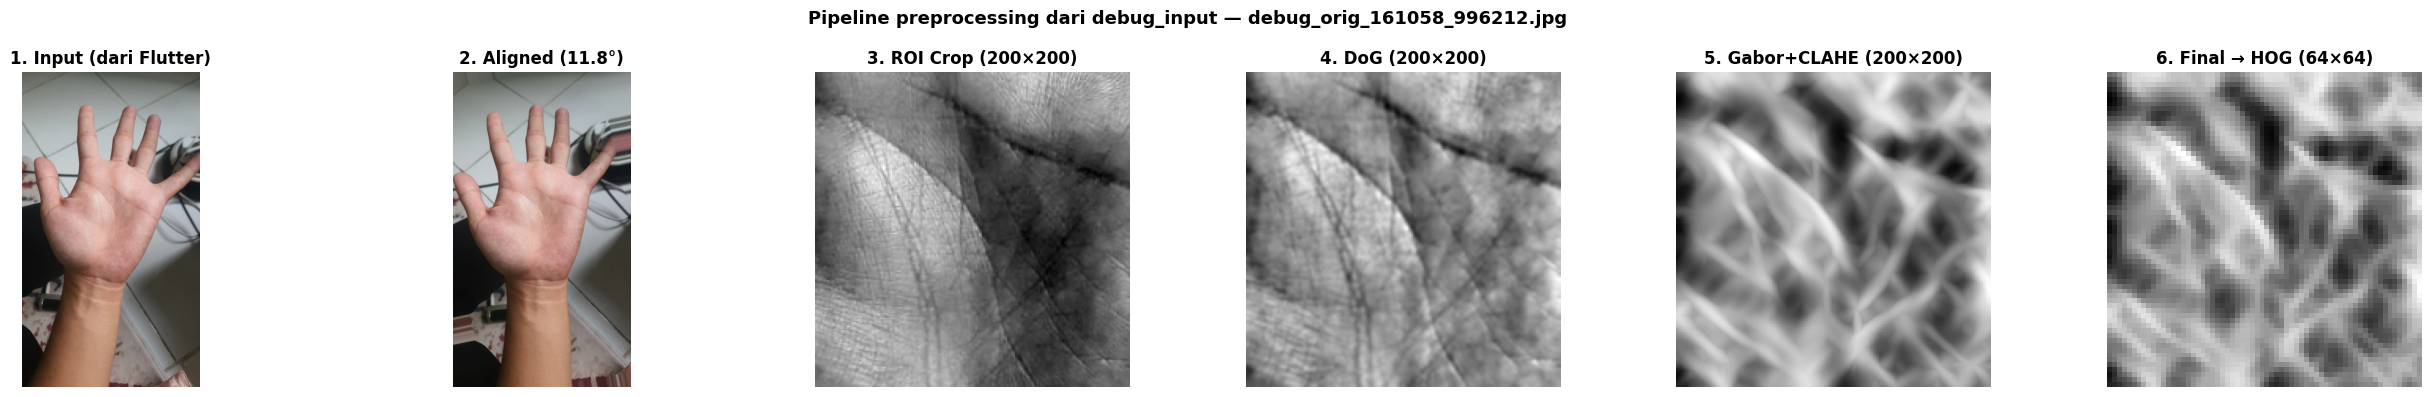

  ROI shape     : (200, 200)
  Angle         : 11.8°
  HOG input     : (64, 64)


In [6]:
# =============================================================================
# HELPER — salin dari extractor.py agar cell ini standalone
# =============================================================================

def normalize_illumination(img_gray: np.ndarray) -> np.ndarray:
    img_f   = img_gray.astype(np.float32)
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=1.0)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=15.0)
    dog     = g_small - g_large
    return cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def enhance_gabor(img_gray: np.ndarray, use_dog: bool = True) -> np.ndarray:
    if use_dog:
        img_gray = normalize_illumination(img_gray)

    responses = []
    for theta in GABOR_THETAS:
        kernel = cv2.getGaborKernel(
            ksize=(GABOR_KSIZE, GABOR_KSIZE),
            sigma=GABOR_SIGMA,
            theta=theta,
            lambd=GABOR_LAMBDA,
            gamma=GABOR_GAMMA,
            psi=0,
            ktype=cv2.CV_32F,
        )
        resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
        responses.append(np.abs(resp))

    gabor_max = np.max(responses, axis=0)
    gabor_max = cv2.normalize(gabor_max, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
    return clahe.apply(gabor_max)


# =============================================================================
# LOAD DEBUG_INPUT
# Prioritas:
#   1. Jika DEBUG_DIR ada, pakai file terbaru di sana
#   2. Fallback: minta path manual
# =============================================================================

def load_latest_debug(debug_dir: str = DEBUG_DIR) -> tuple[str, np.ndarray] | None:
    """
    Cari file debug_input terbaru di debug_dir.
    Return (filepath, img_bgr) atau None jika tidak ada.
    """
    exts = ("*.jpg", "*.jpeg", "*.png")
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(debug_dir, ext)))

    if not files:
        return None

    # Urutkan berdasarkan waktu modifikasi — ambil yang terbaru
    latest = sorted(files, key=os.path.getmtime)[-1]
    img = cv2.imread(latest)
    if img is None:
        return None
    return latest, img


def load_debug_image(path: str) -> np.ndarray | None:
    """Load gambar dari path eksplisit."""
    img = cv2.imread(path)
    return img


# =============================================================================
# VISUALISASI SATU FILE
# Catatan: debug_input sudah berupa ROI grayscale 200×200 hasil MediaPipe.
# Kita TIDAK memanggil detect_palm_opencv() lagi — gambar ini adalah output-nya.
# =============================================================================

def visualize_pipeline(img_input: np.ndarray, title_suffix: str = "") -> None:
    """
    Jalankan dan tampilkan 6 tahap pipeline pada satu gambar input.

    Args:
        img_input    : gambar input — bisa full frame BGR ATAU ROI grayscale 200×200
        title_suffix : string tambahan di judul (misal: nama file)
    """
    # ── Deteksi apakah input sudah ROI (grayscale 200×200) atau full frame BGR ──
    is_roi_only = (
        len(img_input.shape) == 2 and
        img_input.shape == (ROI_SIZE, ROI_SIZE)
    )

    if is_roi_only:
        # debug_input sudah ROI grayscale dari server — tidak ada full frame / aligned
        roi_gray    = img_input
        img_display = cv2.cvtColor(roi_gray, cv2.COLOR_GRAY2RGB)  # panel 1 fallback
        aligned_display = img_display                             # panel 2 fallback
        angle_str   = "N/A (debug ROI)"
    else:
        # Full frame BGR — jalankan MediaPipe
        try:
            from roi_mediapipe import detect_palm_opencv
            roi_gray, dbg = detect_palm_opencv(img_input)
            img_display     = cv2.cvtColor(img_input, cv2.COLOR_BGR2RGB)
            aligned_display = cv2.cvtColor(dbg["img_aligned"], cv2.COLOR_BGR2RGB)
            angle_str       = f"{dbg['angle']:.1f}°"
        except ImportError:
            print("[WARNING] roi_mediapipe tidak tersedia. Convert ke gray sebagai ROI.")
            roi_gray        = cv2.cvtColor(img_input, cv2.COLOR_BGR2GRAY)
            roi_gray        = cv2.resize(roi_gray, (ROI_SIZE, ROI_SIZE))
            img_display     = cv2.cvtColor(img_input, cv2.COLOR_BGR2RGB)
            aligned_display = img_display
            angle_str       = "N/A"

    # ── Pipeline preprocessing (SAMA dengan extractor.py) ──
    dog_img     = normalize_illumination(roi_gray)
    gabor_img   = enhance_gabor(roi_gray, use_dog=True)        # Gabor+DoG+CLAHE
    hog_input   = cv2.resize(
        gabor_img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA
    )

    # ── Plot 6 panel ──
    fig, axes = plt.subplots(1, 6, figsize=(26, 4))
    fig.suptitle(
        f"Pipeline preprocessing dari debug_input{(' — ' + title_suffix) if title_suffix else ''}",
        fontsize=13,
        fontweight="bold",
    )

    axes[0].imshow(img_display)
    axes[0].set_title("1. Input (dari Flutter)", fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(aligned_display)
    axes[1].set_title(f"2. Aligned ({angle_str})", fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(roi_gray, cmap="gray")
    axes[2].set_title(f"3. ROI Crop ({ROI_SIZE}×{ROI_SIZE})", fontweight="bold")
    axes[2].axis("off")

    axes[3].imshow(dog_img, cmap="gray")
    axes[3].set_title(f"4. DoG ({ROI_SIZE}×{ROI_SIZE})", fontweight="bold")
    axes[3].axis("off")

    axes[4].imshow(gabor_img, cmap="gray")
    axes[4].set_title(f"5. Gabor+CLAHE ({ROI_SIZE}×{ROI_SIZE})", fontweight="bold")
    axes[4].axis("off")

    axes[5].imshow(hog_input, cmap="gray")
    axes[5].set_title(f"6. Final → HOG ({IMAGE_SIZE}×{IMAGE_SIZE})", fontweight="bold")
    axes[5].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"  ROI shape     : {roi_gray.shape}")
    print(f"  Angle         : {angle_str}")
    print(f"  HOG input     : {hog_input.shape}")


# =============================================================================
# VISUALISASI SEMUA FILE DI debug_inputs (grid multi-row)
# =============================================================================

def visualize_all_debug(debug_dir: str = DEBUG_DIR, max_files: int = 10) -> None:
    """
    Load semua file di debug_inputs dan tampilkan pipeline tiap file
    dalam satu figure multi-row (1 row = 1 file, 6 kolom).
    """
    exts = ("*.jpg", "*.jpeg", "*.png")
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(debug_dir, ext)))

    if not files:
        print(f"[ERROR] Tidak ada file di: {debug_dir}")
        return

    files = sorted(files, key=os.path.getmtime)[-max_files:]
    n = len(files)
    print(f"[INFO] Memvisualisasikan {n} file dari {debug_dir}")

    fig = plt.figure(figsize=(26, 4 * n))
    fig.suptitle(
        f"Pipeline debug_input — {n} file terbaru",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )

    col_titles = [
        "1. Input (Flutter)",
        "2. Aligned",
        f"3. ROI {ROI_SIZE}×{ROI_SIZE}",
        f"4. DoG {ROI_SIZE}×{ROI_SIZE}",
        f"5. Gabor+CLAHE {ROI_SIZE}×{ROI_SIZE}",
        f"6. HOG input {IMAGE_SIZE}×{IMAGE_SIZE}",
    ]

    gs = gridspec.GridSpec(n, 6, figure=fig, hspace=0.4, wspace=0.05)

    for row, fpath in enumerate(files):
        img_bgr = cv2.imread(fpath)
        if img_bgr is None:
            continue

        fname = os.path.basename(fpath)

        is_roi_only = (
            len(img_bgr.shape) == 3 and
            img_bgr.shape[:2] == (ROI_SIZE, ROI_SIZE)
        ) or (
            len(img_bgr.shape) == 2 and
            img_bgr.shape == (ROI_SIZE, ROI_SIZE)
        )

        # debug_input dari extractor.py adalah grayscale ROI 200×200
        # disimpan dengan cv2.imwrite → dibaca sebagai BGR, tapi channel identik
        if is_roi_only:
            roi_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if len(img_bgr.shape) == 3 else img_bgr
            img_disp    = cv2.cvtColor(roi_gray, cv2.COLOR_GRAY2RGB)
            align_disp  = img_disp
            angle_str   = "ROI only"
        else:
            try:
                from roi_mediapipe import detect_palm_opencv
                roi_gray, dbg = detect_palm_opencv(img_bgr)
                img_disp    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                align_disp  = cv2.cvtColor(dbg["img_aligned"], cv2.COLOR_BGR2RGB)
                angle_str   = f"{dbg['angle']:.1f}°"
            except Exception as e:
                print(f"  [WARN] {fname}: {e}")
                roi_gray   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                roi_gray   = cv2.resize(roi_gray, (ROI_SIZE, ROI_SIZE))
                img_disp   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                align_disp = img_disp
                angle_str  = "err"

        dog_img   = normalize_illumination(roi_gray)
        gabor_img = enhance_gabor(roi_gray, use_dog=True)
        hog_in    = cv2.resize(gabor_img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

        panels = [img_disp, align_disp, roi_gray, dog_img, gabor_img, hog_in]
        cmaps  = [None, None, "gray", "gray", "gray", "gray"]

        for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(panel, cmap=cmap)
            ax.axis("off")
            if row == 0:
                ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=4)
            if col == 0:
                short = fname[:28] + "…" if len(fname) > 30 else fname
                ax.set_ylabel(short, fontsize=8, rotation=0, labelpad=80, va="center")

    plt.savefig(
        os.path.join(debug_dir, "pipeline_vis_all.png"),
        dpi=100,
        bbox_inches="tight",
    )
    print(f"[INFO] Saved: {os.path.join(debug_dir, 'pipeline_vis_all.png')}")
    plt.show()


# =============================================================================
# ENTRY POINT — jalankan cell ini langsung
# =============================================================================

# ── Mode 1: visualisasi file debug_input terbaru ──
result = load_latest_debug(DEBUG_DIR)

if result is None:
    print(f"[ERROR] Tidak ada file di '{DEBUG_DIR}'")
    print("  Pastikan Flutter sudah mengirim gambar dan server sudah menyimpan debug_input.")
else:
    fpath, img_bgr = result
    print(f"[INFO] File: {fpath}  |  shape: {img_bgr.shape}")
    visualize_pipeline(img_bgr, title_suffix=os.path.basename(fpath))

# ── Mode 2: visualisasi semua file (uncomment untuk aktifkan) ──
# visualize_all_debug(DEBUG_DIR, max_files=10)